In [2]:
import os
import glob
import tifffile
import numpy

from matplotlib import pyplot
from skimage.measure import label, regionprops

import sys
to_insert = ".."
while to_insert in sys.path:
    sys.path.remove(to_insert)
sys.path.insert(0, to_insert)

from wavelet_SODA import DetectionWavelets

There are 4 in this folder
Processing file: \\PDK-NAS\Users2\jchabbert\Hydrargyrus\ANALYSIS\pySODA\Control_double_labeling\20250821_8DPF_NbPSD95-Atto643_MsMAGUK-AF594_STED1_Pallium_tif.tif
Channel 0, N before: 1271
Channel 0, N after: 273
Channel 1, N before: 1096
Channel 1, N after: 347


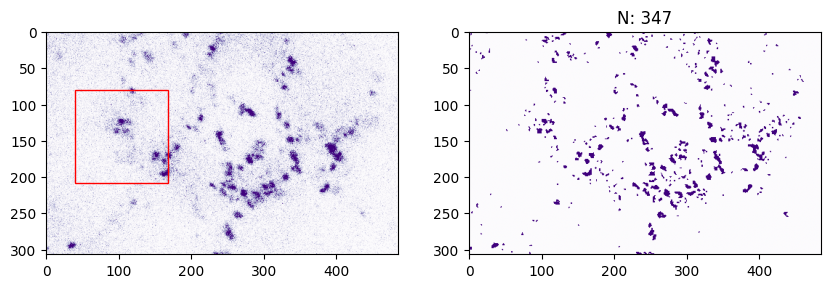

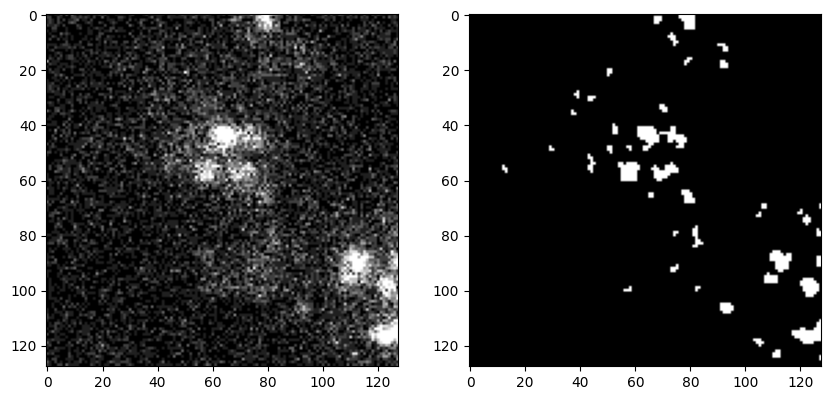

Processing file: \\PDK-NAS\Users2\jchabbert\Hydrargyrus\ANALYSIS\pySODA\Control_double_labeling\20250821_8DPF_NbPSD95-Atto643_MsPSD95-AF594_STED1_Pallium_tif.tif
Channel 0, N before: 1178
Channel 0, N after: 531
Channel 1, N before: 1237
Channel 1, N after: 595


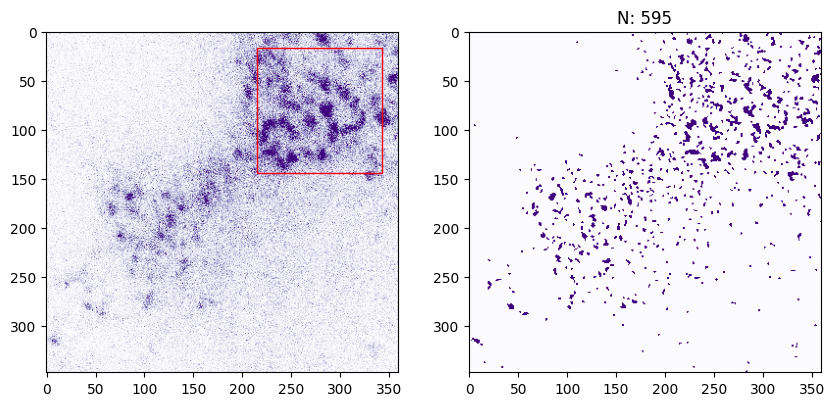

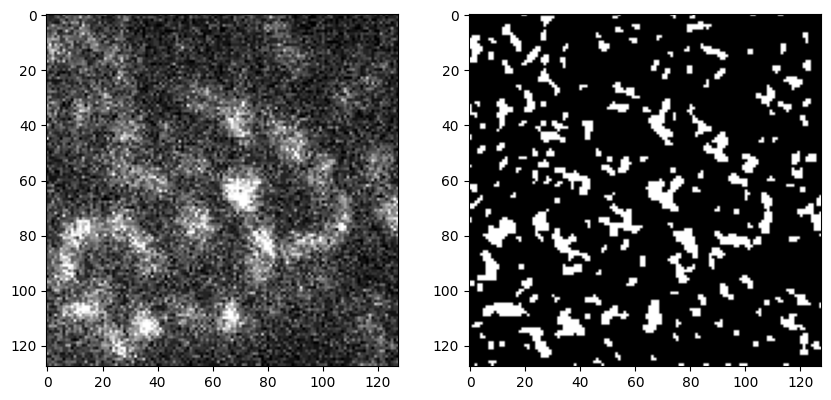

Processing file: \\PDK-NAS\Users2\jchabbert\Hydrargyrus\ANALYSIS\pySODA\Control_double_labeling\20250821_8DPF_NbPSD95-Atto643_MsPSD95-AF594_STED_Habenula_tif.tif
Channel 0, N before: 2721
Channel 0, N after: 1196
Channel 1, N before: 2911
Channel 1, N after: 1308


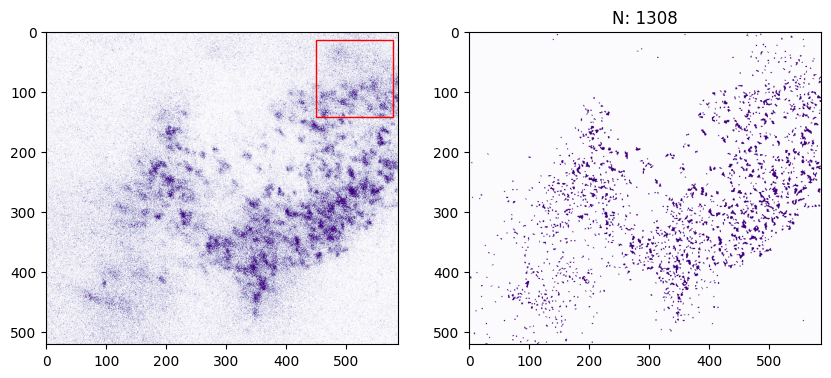

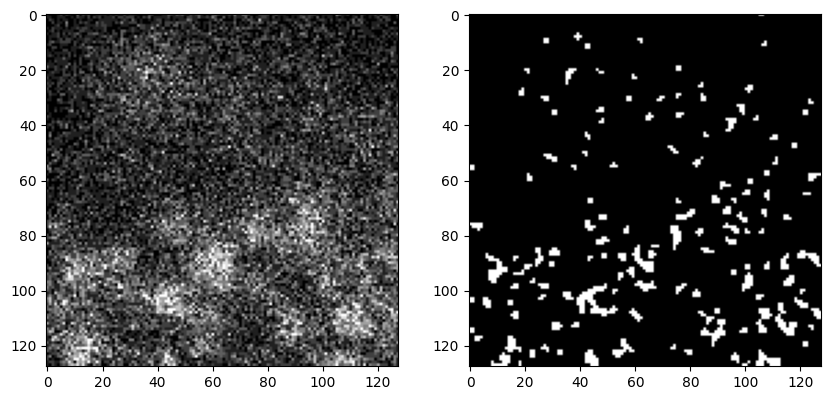

Processing file: \\PDK-NAS\Users2\jchabbert\Hydrargyrus\ANALYSIS\pySODA\Control_double_labeling\20250912_5DPF_CTRL_Casper_GPigBassoon-star635P_RbRIM-AF594_STED2-AO_neuropile.tif
Channel 0, N before: 1699
Channel 0, N after: 963
Channel 1, N before: 2115
Channel 1, N after: 1214


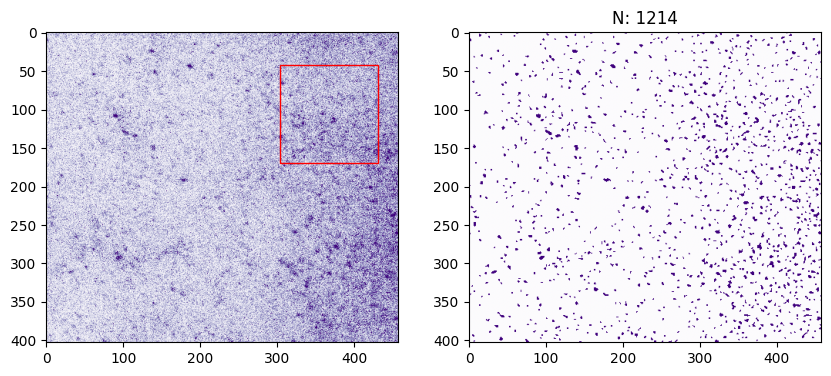

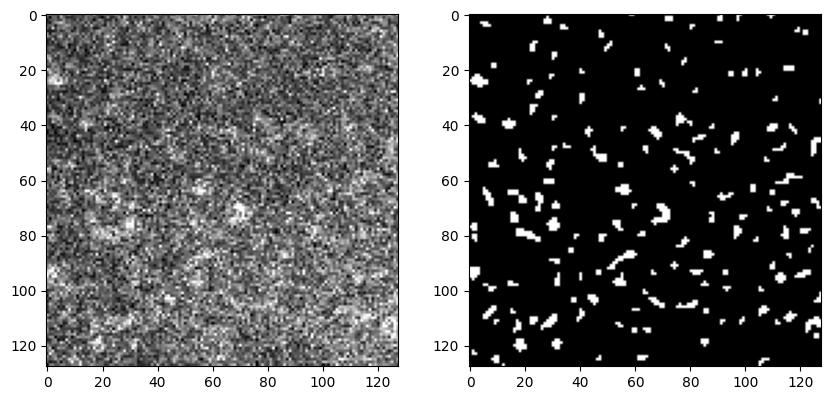

In [21]:
%matplotlib inline

PATH = r"\\PDK-NAS\Users2\jchabbert\Hydrargyrus\ANALYSIS\pySODA\Control_double_labeling"
#PATH = r"\\PDK-NAS\Users2\jchabbert\Hydrargyrus\ANALYSIS\pySODA\Control_double_labeling\output_doublepre_ipynb"
files = glob.glob(os.path.join(PATH, "*.tif"))
print(f'There are {len(files)} in this folder')

SCALE_LIST = [[2],  # Channel 0  # Scales to be used for wavelet transform for spot detection
              [2],  # Channel 1  # Higher values mean less details.
              [2]]  # Channel 2  # Multiple scales can be used (e.g. [1,2]). Scales must be integers.
SCALE_THRESHOLD = [2,  # Channel 0  # Multiplier of wavelet transform threshold.
                   2,  # Channel 1  # Higher value = more pixels detected.
                   2]  # Channel 2
chan_idx = 1  # Choose channel to display

for file in files:
    print("Processing file: {}".format(file))

    stack = tifffile.imread(file)

    if stack.min() != 0:
        stack = stack - stack.min()
    mask = numpy.zeros(stack.shape, dtype=bool)
    
    for i in range(stack.shape[0]):
        mask[i] = DetectionWavelets(stack[i], SCALE_LIST[i], SCALE_THRESHOLD[i]).computeDetection()
    
    labels = [label(mask[i]) for i in range(mask.shape[0])]
    props = [regionprops(labels[i], intensity_image=stack[i]) for i in range(mask.shape[0])]

    # fig, ax = pyplot.subplots()
    # ax.hist([p.area for p in props[chan_idx]], bins=50, range=(0, 250))
    # ax.set_title(f"N: {len(props[chan_idx])}")
    # pyplot.show()

    # fig, ax = pyplot.subplots()
    # ax.hist([p.intensity_mean for p in props[chan_idx]], bins=50, range=(0, 100))
    # ax.set_title(f"N: {len(props[chan_idx])}")
    # pyplot.show()    

    # Remove small objects
    min_size = 3
    min_intensity = 3
    
    for i in range(mask.shape[0]):
        print("Channel {}, N before: {}".format(i, len(props[i])))
        background_level = numpy.quantile(stack[i], 0.05)
        for p in props[i]:
            if p.area < min_size:
                mask[i][labels[i] == p.label] = 0
            if p.intensity_mean < min_intensity + background_level:
                mask[i][labels[i] == p.label] = 0

        labels[i] = label(mask[i])
        props[i] = regionprops(labels[i])
        print("Channel {}, N after: {}".format(i, len(props[i])))
    mask = numpy.array(labels, dtype=bool).copy()

    fig, axes = pyplot.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(stack[chan_idx], cmap="Purples", vmin=0, vmax=numpy.quantile(stack[chan_idx], 0.99))
    axes[1].imshow(mask[chan_idx], cmap="Purples")
    axes[1].set_title("N: {}".format(len(props[chan_idx])))

    # Center and crop around center
    center = numpy.array(stack.shape[1:]) // 2
    size = 128
    center = numpy.random.randint(size // 2, [s-size // 2 for s in stack.shape[1:]], size=2)

    stack = stack[:, center[0]-size//2:center[0]+size//2, center[1]-size//2:center[1]+size//2]
    mask = mask[:, center[0]-size//2:center[0]+size//2, center[1]-size//2:center[1]+size//2]
    axes[0].add_patch(pyplot.Rectangle((center[1]-size//2, center[0]-size//2), size, size, fill=False, color="red"))

    fig, axes = pyplot.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(stack[chan_idx], cmap="gray", vmin=0, vmax=numpy.quantile(stack[chan_idx], 0.99))

    axes[1].imshow(mask[chan_idx], cmap="gray")
    pyplot.show()

    # break
    